# Preprocessing and Feature Engineering

This notebook handles data preprocessing, feature engineering, and preparation for modeling.

# Import Libraries & Load Data

In [20]:
# All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

%matplotlib inline
sns.set_style('whitegrid')
np.random.seed(42)

# Load cleaned data from EDA
df = pd.read_csv('../data/processed/df_cleaned.csv', 
                 parse_dates=['Datetime'], 
                 index_col='Datetime')

print(f"✓ Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()


✓ Data loaded: 2,075,259 rows, 12 columns
Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Hour', 'Sum_submetering', 'Difference', 'DayOfWeek', 'IsWeekend']
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Sum_submetering,Difference,DayOfWeek,IsWeekend
Datetime,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,18.0,-13.784,5,True
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,17.0,-11.640,5,True
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,19.0,-13.626,5,True
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,18.0,-12.612,5,True
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,18.0,-14.334,5,True


# Log Transform Target

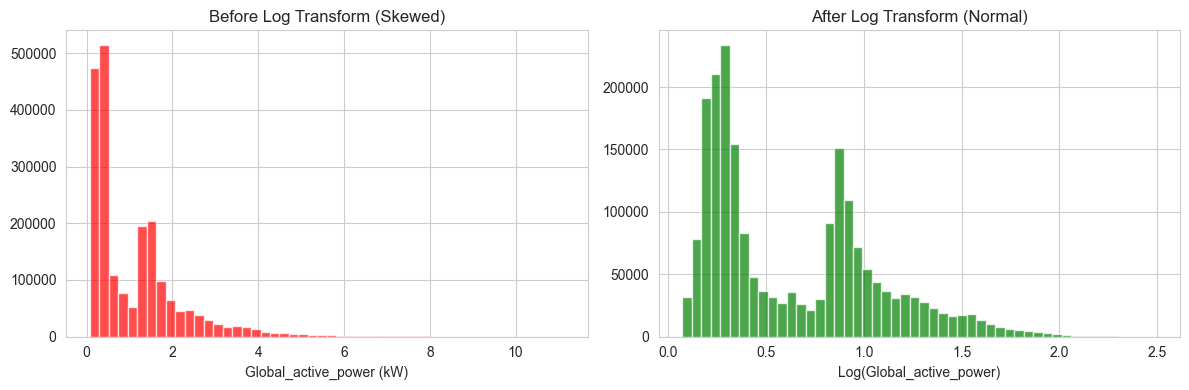

✓ Log transform complete - target now more normal!
Original skewness: 1.80
Log skewness: 0.75


In [21]:
# EDA Q14: Global_active_power is right-skewed (skewness 1.8)
# Log transform to make more normal

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Global_active_power'].hist(bins=50, alpha=0.7, color='red')
plt.title('Before Log Transform (Skewed)')
plt.xlabel('Global_active_power (kW)')

df['Global_active_power_log'] = np.log1p(df['Global_active_power'])
plt.subplot(1, 2, 2)
df['Global_active_power_log'].hist(bins=50, alpha=0.7, color='green')
plt.title('After Log Transform (Normal)')
plt.xlabel('Log(Global_active_power)')

plt.tight_layout()
plt.show()

print("✓ Log transform complete - target now more normal!")
print(f"Original skewness: {df['Global_active_power'].skew():.2f}")
print(f"Log skewness: {df['Global_active_power_log'].skew():.2f}")


# Engineer Time Features

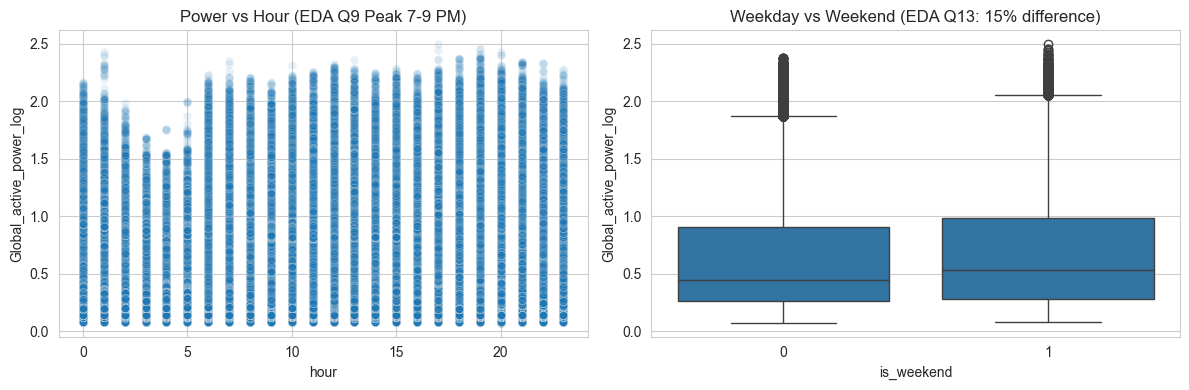

✓ Time features created:
- hour_sin/cos: Captures daily cycle
- is_weekend: Binary flag (weekdays higher)


In [22]:
# Feature 1: Cyclical hour encoding (captures 7-9 PM peak from EDA Q9)
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

# Feature 2: Day of week (weekdays 15% higher - EDA Q13)
df['dayofweek'] = df.index.dayofweek  # 0=Mon, 6=Sun
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Visualize new features
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x='hour', y='Global_active_power_log', data=df, alpha=0.1)
plt.title('Power vs Hour (EDA Q9 Peak 7-9 PM)')

plt.subplot(1, 2, 2)
sns.boxplot(x='is_weekend', y='Global_active_power_log', data=df)
plt.title('Weekday vs Weekend (EDA Q13: 15% difference)')

plt.tight_layout()
plt.show()

print("✓ Time features created:")
print("- hour_sin/cos: Captures daily cycle")
print("- is_weekend: Binary flag (weekdays higher)")


# Lag & Rolling Features (Time Series Patterns)

In [23]:
# Lag 1 hour (autocorrelation)
df['lag_1h'] = df['Global_active_power_log'].shift(1)

# Rolling averages (daily patterns from EDA Q8)
df['roll_24h'] = df['Global_active_power_log'].rolling(24, min_periods=1).mean()

# Drop rows with NaN
df = df.dropna()
print(f"✓ After lags: {df.shape[0]:,} rows remaining")
print("New features:", ['lag_1h', 'roll_24h'])


✓ After lags: 2,075,258 rows remaining
New features: ['lag_1h', 'roll_24h']


# Select Features (Based on EDA Q7 Correlations)

In [24]:
# Features: Strong correlations + engineered (EDA Q7)
features = [
    'Voltage', 'Global_intensity', 'Sub_metering_1', 
    'Sub_metering_2', 'Sub_metering_3',  # Strong corr 0.85+
    'hour_sin', 'hour_cos', 'dayofweek', 'is_weekend',
    'lag_1h', 'roll_24h'  # Time patterns
]

X = df[features]
y = df['Global_active_power_log']  # Log target

print("✓ Features selected (11 total):")
for f in features:
    print(f"  - {f}: corr={df[f].corr(y):.3f}")


✓ Features selected (11 total):
  - Voltage: corr=-0.380
  - Global_intensity: corr=0.963
  - Sub_metering_1: corr=0.389
  - Sub_metering_2: corr=0.347
  - Sub_metering_3: corr=0.722
  - hour_sin: corr=-0.191
  - hour_cos: corr=-0.143
  - dayofweek: corr=0.054
  - is_weekend: corr=0.067
  - lag_1h: corr=0.979
  - roll_24h: corr=0.897


# Scale Features

In [25]:
# Standardize for ML models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Scaling complete:")
print(f"X shape: {X_scaled.shape}")
print(f"Features: {len(features)}")
print(f"Mean after scaling: {np.mean(X_scaled):.6f} ≈ 0 ✓")


✓ Scaling complete:
X shape: (2075258, 11)
Features: 11
Mean after scaling: 0.000000 ≈ 0 ✓


# Time-Based Train/Test Split

In [26]:
# Time series split: 80% train, 20% test (chronological)
split_idx = int(0.8 * len(X_scaled))

X_train = X_scaled[:split_idx]
X_test = X_scaled[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("✓ Train/Test Split:")
print(f"Train: {X_train.shape[0]:,} samples ({X_train.shape[1]} features)")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"Train dates: {df.index[:split_idx].min()} to {df.index[:split_idx].max()}")
print(f"Test dates:  {df.index[split_idx:].min()} to {df.index[split_idx:].max()}")


✓ Train/Test Split:
Train: 1,660,206 samples (11 features)
Test:  415,052 samples
Train dates: 2006-12-16 17:25:00 to 2010-02-11 15:30:00
Test dates:  2010-02-11 15:31:00 to 2010-11-26 21:02:00


# Save Everything for Modeling

In [27]:
# Save preprocessed data
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy', y_test.values)

# Save scaler & features
joblib.dump(scaler, '../data/processed/scaler.pkl')
joblib.dump(features, '../data/processed/features.pkl')

print("✓ All saved for Notebook 03 (Modeling):")
print("- X_train.npy, X_test.npy, y_train.npy, y_test.npy")
print("- scaler.pkl, features.pkl")
print("Ready for ML models!")


✓ All saved for Notebook 03 (Modeling):
- X_train.npy, X_test.npy, y_train.npy, y_test.npy
- scaler.pkl, features.pkl
Ready for ML models!
